# S3 数据处理与分析: Questions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False 

## Q1: 学生成绩计算

In [2]:
marks = pd.read_excel('marks.xlsx', 'Sheet1', dtype={"学号": str})
marks.head(5)

,班级,学号,期中成绩,期末成绩,平时成绩,实验成绩
0,网络01,07020511,89,79,93,87
1,网络01,07020206,66,56,78,84
2,网络01,07020213,88,57,88,84
3,网络01,07020217,81,61,88,87
4,网络01,07020308,81,70,90,83


In [3]:
marks['总评成绩'] = (marks['期中成绩']*0.2 + marks['期末成绩']*0.3 + marks['平时成绩']*0.2 + marks['实验成绩']*0.3).round().astype(int)
marks.head(5)

,班级,学号,期中成绩,期末成绩,平时成绩,实验成绩,总评成绩
0,网络01,07020511,89,79,93,87,86
1,网络01,07020206,66,56,78,84,71
2,网络01,07020213,88,57,88,84,78
3,网络01,07020217,81,61,88,87,78
4,网络01,07020308,81,70,90,83,80


In [4]:
marks['目标1'] = ((marks['平时成绩']*0.06 + marks['期中成绩']*0.14 + marks['期末成绩']*0.18 + marks['实验成绩']*0.12)/50).round(2)
marks['目标2'] = ((marks['平时成绩']*0.14 + marks['期中成绩']*0.06 + marks['期末成绩']*0.12 + marks['实验成绩']*0.18)/50).round(2)
marks.head(5)

,班级,学号,期中成绩,期末成绩,平时成绩,实验成绩,总评成绩,目标1,目标2
0,网络01,07020511,89,79,93,87,86,0.85,0.87
1,网络01,07020206,66,56,78,84,71,0.68,0.73
2,网络01,07020213,88,57,88,84,78,0.76,0.79
3,网络01,07020217,81,61,88,87,78,0.76,0.80
4,网络01,07020308,81,70,90,83,80,0.79,0.82


In [5]:
# 按总评成绩排序
marks.sort_values('总评成绩', ascending=False).head(5)

,班级,学号,期中成绩,期末成绩,平时成绩,实验成绩,总评成绩,目标1,目标2
11,网络01,07020407,86,85,98,95,91,0.89,0.92
64,网络02,07020731,80,90,95,95,90,0.89,0.92
10,网络01,07020403,95,85,87,95,90,0.90,0.90
42,网络02,07020409,94,81,98,87,89,0.88,0.89
35,网络02,07020222,85,78,95,91,87,0.85,0.88


## Q2: 学生成绩统计

### 统计量

In [6]:
marks.describe()

,期中成绩,期末成绩,平时成绩,实验成绩,总评成绩,目标1,目标2
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,81.523077,69.400000,88.584615,83.584615,79.892308,0.784462,0.813231
std,9.953184,11.095889,6.580968,5.317695,5.823238,0.063468,0.054029
min,54.000000,45.000000,74.000000,68.000000,67.000000,0.640000,0.690000
25%,74.000000,61.000000,84.000000,80.000000,76.000000,0.740000,0.780000
50%,83.000000,67.000000,90.000000,84.000000,80.000000,0.790000,0.820000
75%,90.000000,78.000000,93.000000,87.000000,85.000000,0.830000,0.860000
max,98.000000,95.000000,98.000000,95.000000,91.000000,0.900000,0.920000


In [7]:
# 常用统计量
cols = ['期中成绩', '期末成绩', '平时成绩', '实验成绩', '总评成绩']
marks[cols].apply(['max', 'min', 'mean', 'std', 'median', 'kurt', 'skew'])

# 正态分布峰度为0，偏度为0
# 期中成绩：略低峰，左偏，高分较多，少量低分拉长了尾部
# 期末成绩：低峰，略右偏，大部分成绩集中在中间或偏高的区域，接近正态分布
# 平时成绩：明显低峰，明显左偏，大部分成绩很高
# 实验成绩：高峰，略左偏，成绩集中在一个较高的分数附近，同时存在一些极端高分和极端低分
# 总评成绩：略低峰，轻微左偏，多数成绩较高

,期中成绩,期末成绩,平时成绩,实验成绩,总评成绩
max,98.000000,95.000000,98.000000,95.000000,91.000000
min,54.000000,45.000000,74.000000,68.000000,67.000000
mean,81.523077,69.400000,88.584615,83.584615,79.892308
std,9.953184,11.095889,6.580968,5.317695,5.823238
median,83.000000,67.000000,90.000000,84.000000,80.000000
kurt,-0.252213,-0.503391,-0.648461,0.654592,-0.477156
skew,-0.586829,0.139252,-0.643463,-0.212170,-0.264655


### 绘图

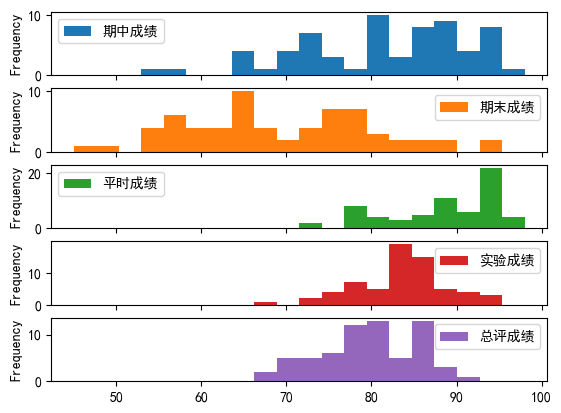

In [8]:
# sns不支持subplots参数
marks[cols].plot.hist(subplots=True, bins=20)
plt.show()

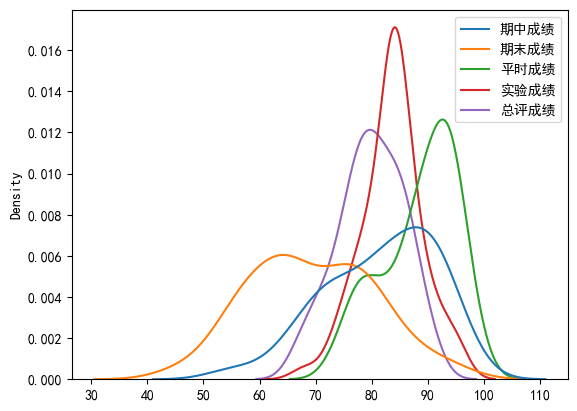

In [9]:
#或 marks[cols].plot.kde()
sns.kdeplot(marks[cols])
plt.show()

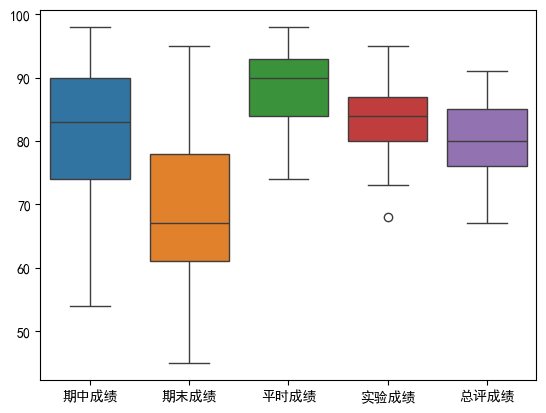

In [10]:
# marks[cols].plot.box()  # 默认无填充色
sns.boxplot(marks[cols])
plt.show()

### 相关性

In [11]:
# 总评成绩与期末成绩强相关
marks[cols].corr()

,期中成绩,期末成绩,平时成绩,实验成绩,总评成绩
期中成绩,1.000000,0.239583,0.435849,0.175688,0.623995
期末成绩,0.239583,1.000000,0.414646,0.317719,0.831815
平时成绩,0.435849,0.414646,1.000000,0.258865,0.687052
实验成绩,0.175688,0.317719,0.258865,1.000000,0.568711
总评成绩,0.623995,0.831815,0.687052,0.568711,1.000000


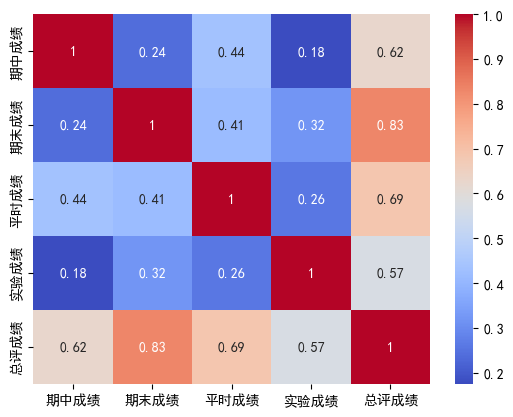

In [12]:
sns.heatmap(marks[cols].corr(), annot=True, cmap='coolwarm')
plt.show()

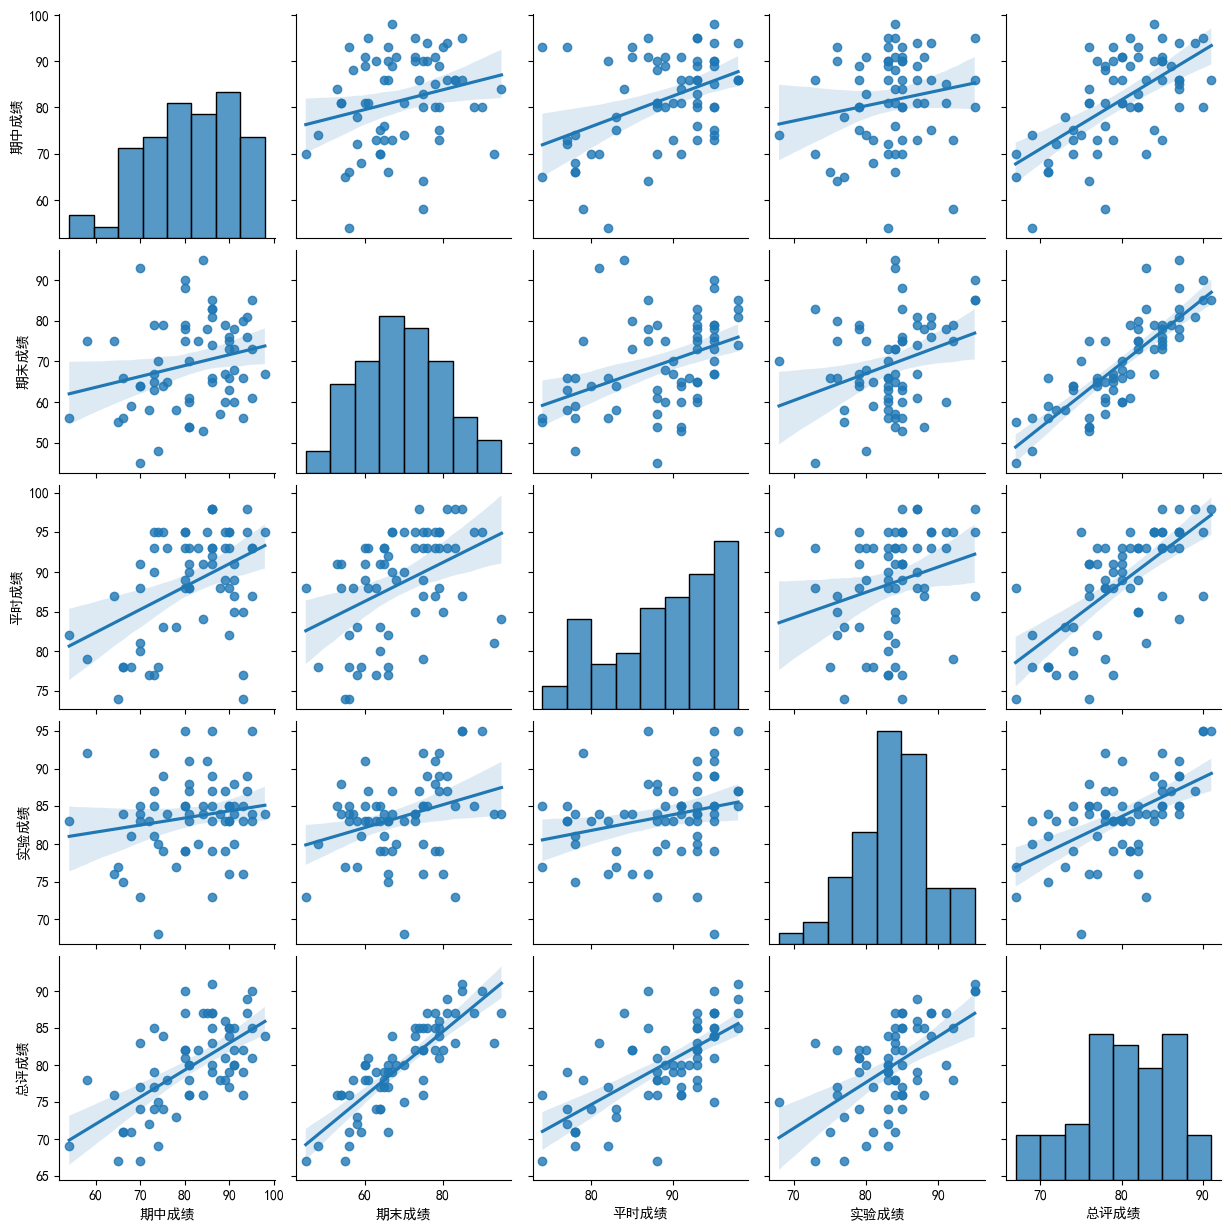

In [13]:
sns.pairplot(marks[cols], kind='reg', diag_kind='hist')
plt.show()

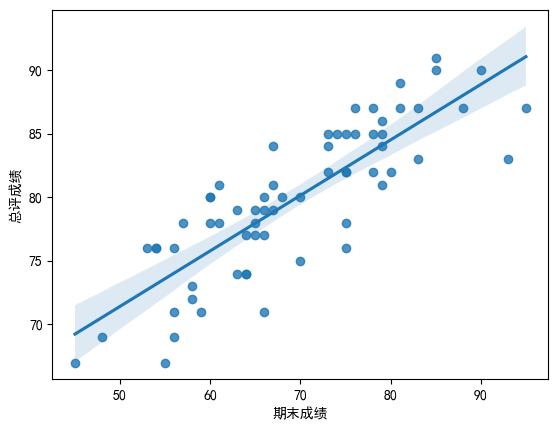

In [14]:
sns.regplot(data=marks, x='期末成绩', y='总评成绩')
plt.show()

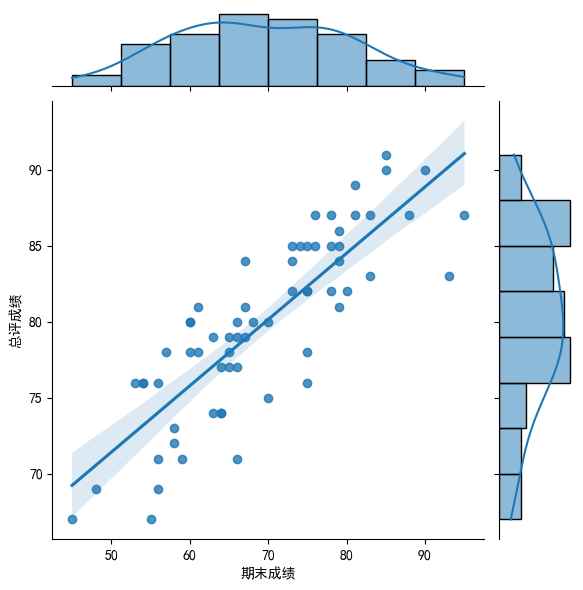

In [15]:
sns.jointplot(data=marks, x='期末成绩', y='总评成绩', kind='reg')
plt.show()

In [16]:
# 期末成绩、实验成绩、总评成绩符合正态分布（夏皮罗检验）
from scipy.stats import shapiro

results = {}
for col in cols:
    stat, p = shapiro(marks[col])
    results[col] = {"stat": stat, "p": p}
pd.DataFrame(results)

,期中成绩,期末成绩,平时成绩,实验成绩,总评成绩
stat,0.956147,0.985360,0.918777,0.969056,0.979514
p,0.021673,0.638842,0.000397,0.102871,0.354848


In [17]:
# 期末成绩与总评成绩显著不同（成对正态样本的t检验）
from scipy.stats import ttest_rel
ttest_rel(marks['期末成绩'], marks['总评成绩'])

TtestResult(statistic=np.float64(-12.019079038991396), pvalue=np.float64(4.6033098528014345e-18), df=np.int64(64))

### 分数段

In [18]:
bins = [0, 60, 70, 80, 90, 101]
labels = ['0~59', '60~69', '70~79', '80~89', '90~100']
marks[cols].apply(
    lambda s: pd.cut(s, bins=bins, labels=labels, right=False).value_counts().sort_index(ascending=False)
)

,期中成绩,期末成绩,平时成绩,实验成绩,总评成绩
90~100,18,3,34,7,3
80~89,25,8,21,44,32
70~79,15,20,10,13,26
60~69,5,21,0,1,4
0~59,2,13,0,0,0


## Q3: 分班讨论

In [19]:
# 两个班的基本统计量
marks.groupby("班级")['总评成绩'].agg(['max', 'min', 'mean', 'median', 'std'])

,max,min,mean,median,std
班级,,,,,
网络01,91,67,80.00000,80.0,5.408327
网络02,90,67,79.78125,80.5,6.307877


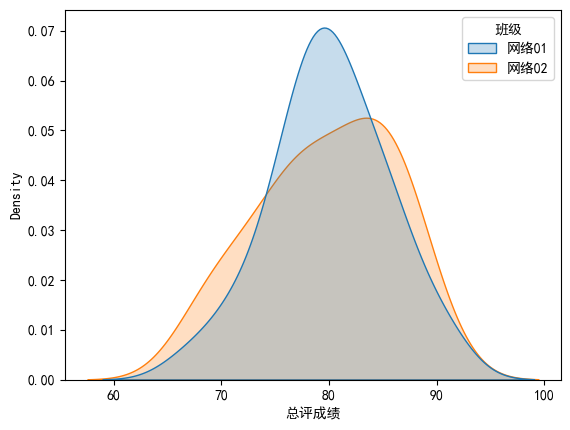

In [20]:
sns.kdeplot(data=marks, x='总评成绩', hue="班级", fill=True, common_norm=False)
plt.show()

# 2班整体成绩较高，1班成绩较集中，极端高分和极端低分差不多

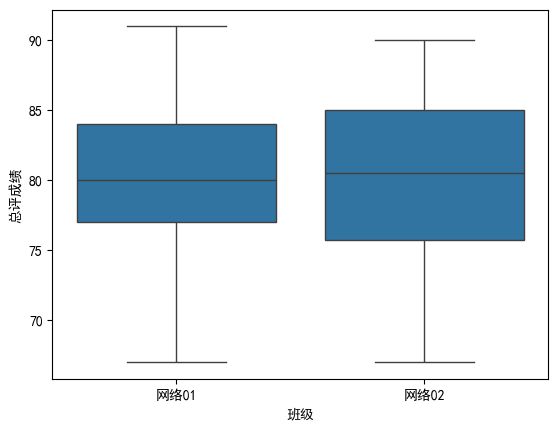

In [21]:
sns.boxplot(data=marks, x='班级', y='总评成绩')
plt.show()

In [22]:
# 两班总评成绩方差相同
from scipy.stats import levene
class01 = marks[marks['班级'] == '网络01']['总评成绩']
class02 = marks[marks['班级'] == '网络02']['总评成绩']
levene(class01, class02)

LeveneResult(statistic=np.float64(1.8790615919477691), pvalue=np.float64(0.17530491369428694))

In [23]:
# 两班总评成绩无差别
from scipy.stats import ttest_ind
ttest_ind(class01, class02, equal_var=True)

TtestResult(statistic=np.float64(0.15025084316876952), pvalue=np.float64(0.8810467310440847), df=np.float64(63.0))